<a href="https://colab.research.google.com/github/linawluv/IS-4487-Labs/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

Choose a City & Upload Your Dataset
📥 Follow these steps:

Go to: https://insideairbnb.com/get-the-data/
Choose a city you’re interested in.
Download the file named: listings.csv.gz under that city.
In your notebook:
Open the left sidebar
Click the folder icon 📁
Click the upload icon ⬆️ and choose your listings.csv.gz file
Use the file path /content/listings.csv.gz when loading your data.
Import standard libraries (pandas, numpy, seaborn, matplotlib)

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/sample_data/cleaned_airbnb_data_6.csv", low_memory=False)

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,934859141300145599,https://www.airbnb.com/rooms/934859141300145599,20260622055616,2026-07-02,previous scrape,An Exquisite Rooftop Studio,Introducing an exquisite rooftop studio in the...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,384892315,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
1,944156894640610027,https://www.airbnb.com/rooms/944156894640610027,20260622055616,2026-06-23,city scrape,Tarrytown bungalow,Take a break and unwind at this peaceful oasis...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,13392053,...,5.00,4.75,4.25,NaN,NaN,1,0,1,0,0.12
2,1634902892490996951,https://www.airbnb.com/rooms/1634902892490996951,20260622055616,2026-06-23,city scrape,Central East Gem near running trail,Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,266329439,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,1308737991593278409,https://www.airbnb.com/rooms/1308737991593278409,20260622055616,2026-06-23,city scrape,Empire,"- Accommodate up to 14 guests, 4-bedroom home<...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,398748229,...,4.93,4.80,4.61,OL2023119758,NaN,4,4,0,0,2.39
4,574582741829434703,https://www.airbnb.com/rooms/574582741829434703,20260622055616,2026-06-23,city scrape,Galaxy by AvantStay | Luxury Amenities in Austin,- Pet-friendly home<br />- Rooftop pool and lo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,434308464,...,4.52,4.97,4.90,NaN,NaN,178,178,0,0,0.60


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

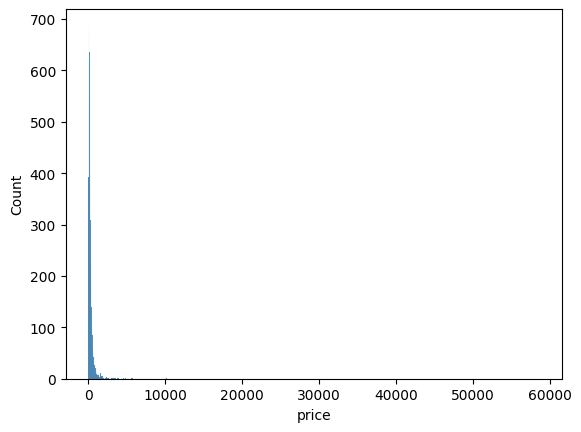

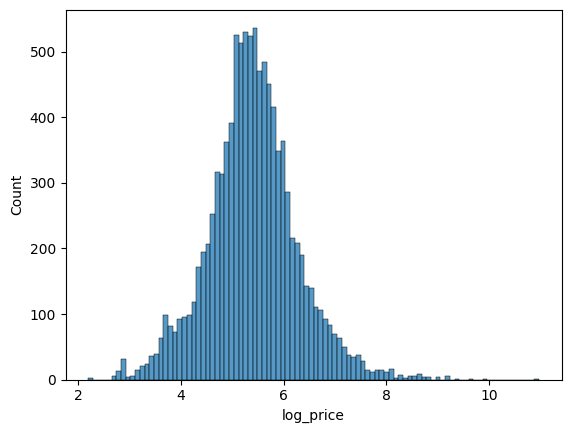

In [10]:
sns.histplot(df["price"])
plt.show()

df["log_price"] = np.log1p(df["price"])

sns.histplot(df["log_price"])
plt.show()

### Reflection:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?

### ✍️ Your Response: 🔧
1. I examined the price column because it was right-skewed

2. I tried a log transformation using np.log1p(). because it will make the distribution less skewed.

3. The transformed version helps make the data easier to visualize and interpret because the higher prices have less effect.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

In [11]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale
minmax = MinMaxScaler()

df["availability_scaled"] = minmax.fit_transform(
    df[["availability_365"]])

# Z-score scale
standard = StandardScaler()

df["reviews_standardized"] = standard.fit_transform(
    df[["number_of_reviews"]])

# To view the new columns
df[["availability_365", "availability_scaled",
    "number_of_reviews", "reviews_standardized"]].head()

,availability_365,availability_scaled,number_of_reviews,reviews_standardized
0,364,0.997260,0,-0.535855
1,360,0.986301,4,-0.498194
2,365,1.000000,0,-0.535855
3,339,0.928767,41,-0.149831
4,357,0.978082,31,-0.243983



### Reflection:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

### ✍️ Your Response: 🔧
1. The two columns I scaled are the availability_365 using the Min-Max scaling and the number_of_reviews using Z-score standardization.

2. These scaled values might be more useful than the originals because scaling helps prevent larger values from automatically having more influence.

3. Data analysts and scientists might benefit from this transformation because they can predict listing performance.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

In [12]:
df["review_activity"] = pd.qcut(df["number_of_reviews"], 3, labels=["Low", "Medium", "High"])

df["review_activity"].value_counts()

,count
review_activity,
Low,3893
High,3728
Medium,3674


### Reflection:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?

### ✍️ Your Response: 🔧
1. I grouped the number_of_reviews into low, medium, and high review activity.

2. Someone might prefer this grouped view over raw numbers to help quickly identidy listings based on customer activity.

3. At Airbnb, this would help marketing managers by identifying listings with low review activity and improve promotion in that certain area.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

In [13]:
df["price_per_guest"] = df["price"] / df["accommodates"]

df["long_term_stay"] = np.where(df["minimum_nights"] >= 30, 1, 0)

### Reflection:
1. What two new columns did you create and why?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

### ✍️ Your Response: 🔧
1. The two columns I created are price_per_guest to show the listing price related to the number of guests and I created the long_term_stay to show listing that needs guests to stay 30 days or more.

2. Hosts and managers could use these for comparing to their competitors and identifying properties that target longer stays.

3. This could help hosts make pricing decisions and help Airbnb find different types of listings and customer trends.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

In [14]:
room_type = pd.get_dummies(df["room_type"], prefix="room_type", dtype=int)

df = pd.concat([df, room_type], axis=1)

### Reflection:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?

### ✍️ Your Response: 🔧
1. I encoded the room_type column because its values are categorical which cannot be used as numeric inputs for a model.
2. I used the one-hot encoding
3. This transformation could help pricing and statistical models to figure out if different types of rooms correlate with the prices.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [15]:
df.to_csv("cleaned_airbnb_data_7.csv", index=False)

## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### Reflection:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. I felt like the log transformation of price was most important because initally, the histogram was really right skewed. I found it interesting that it was a small number of really expensive listings.

2. I think the price_per_guest would be the most useful to a host because it compares pricing between different sizes of listings.

3. If I were to build a dashboard, the next thing I would do with this data is compare the price per guest, listing prices, look over the customer activity, and availability.

4. This related to my customized learning outcome because it was to "build and evaluate a model that forecasts revenue to guide budgeting or investment decisions," thus, transforming this data could help predict financial performance.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"